# Olist Freight Pricing - EDA & BI

**Notebook:** `01_eda_and_bi.ipynb` | **Stage:** 1 | **Figure output:** `img/plots/`

---

## 1. Setup

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.ticker import FuncFormatter

In [2]:
conn = sqlite3.connect('/Volumes/STORAGE/olist-freight-pricing-engine/data/raw/olist.sqlite')

## 2. Database Structure

In [3]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
tables

,name
0,product_category_name_translation
1,sellers
2,customers
3,geolocation
4,order_items
5,order_payments
6,order_reviews
7,orders
8,products
9,leads_qualified


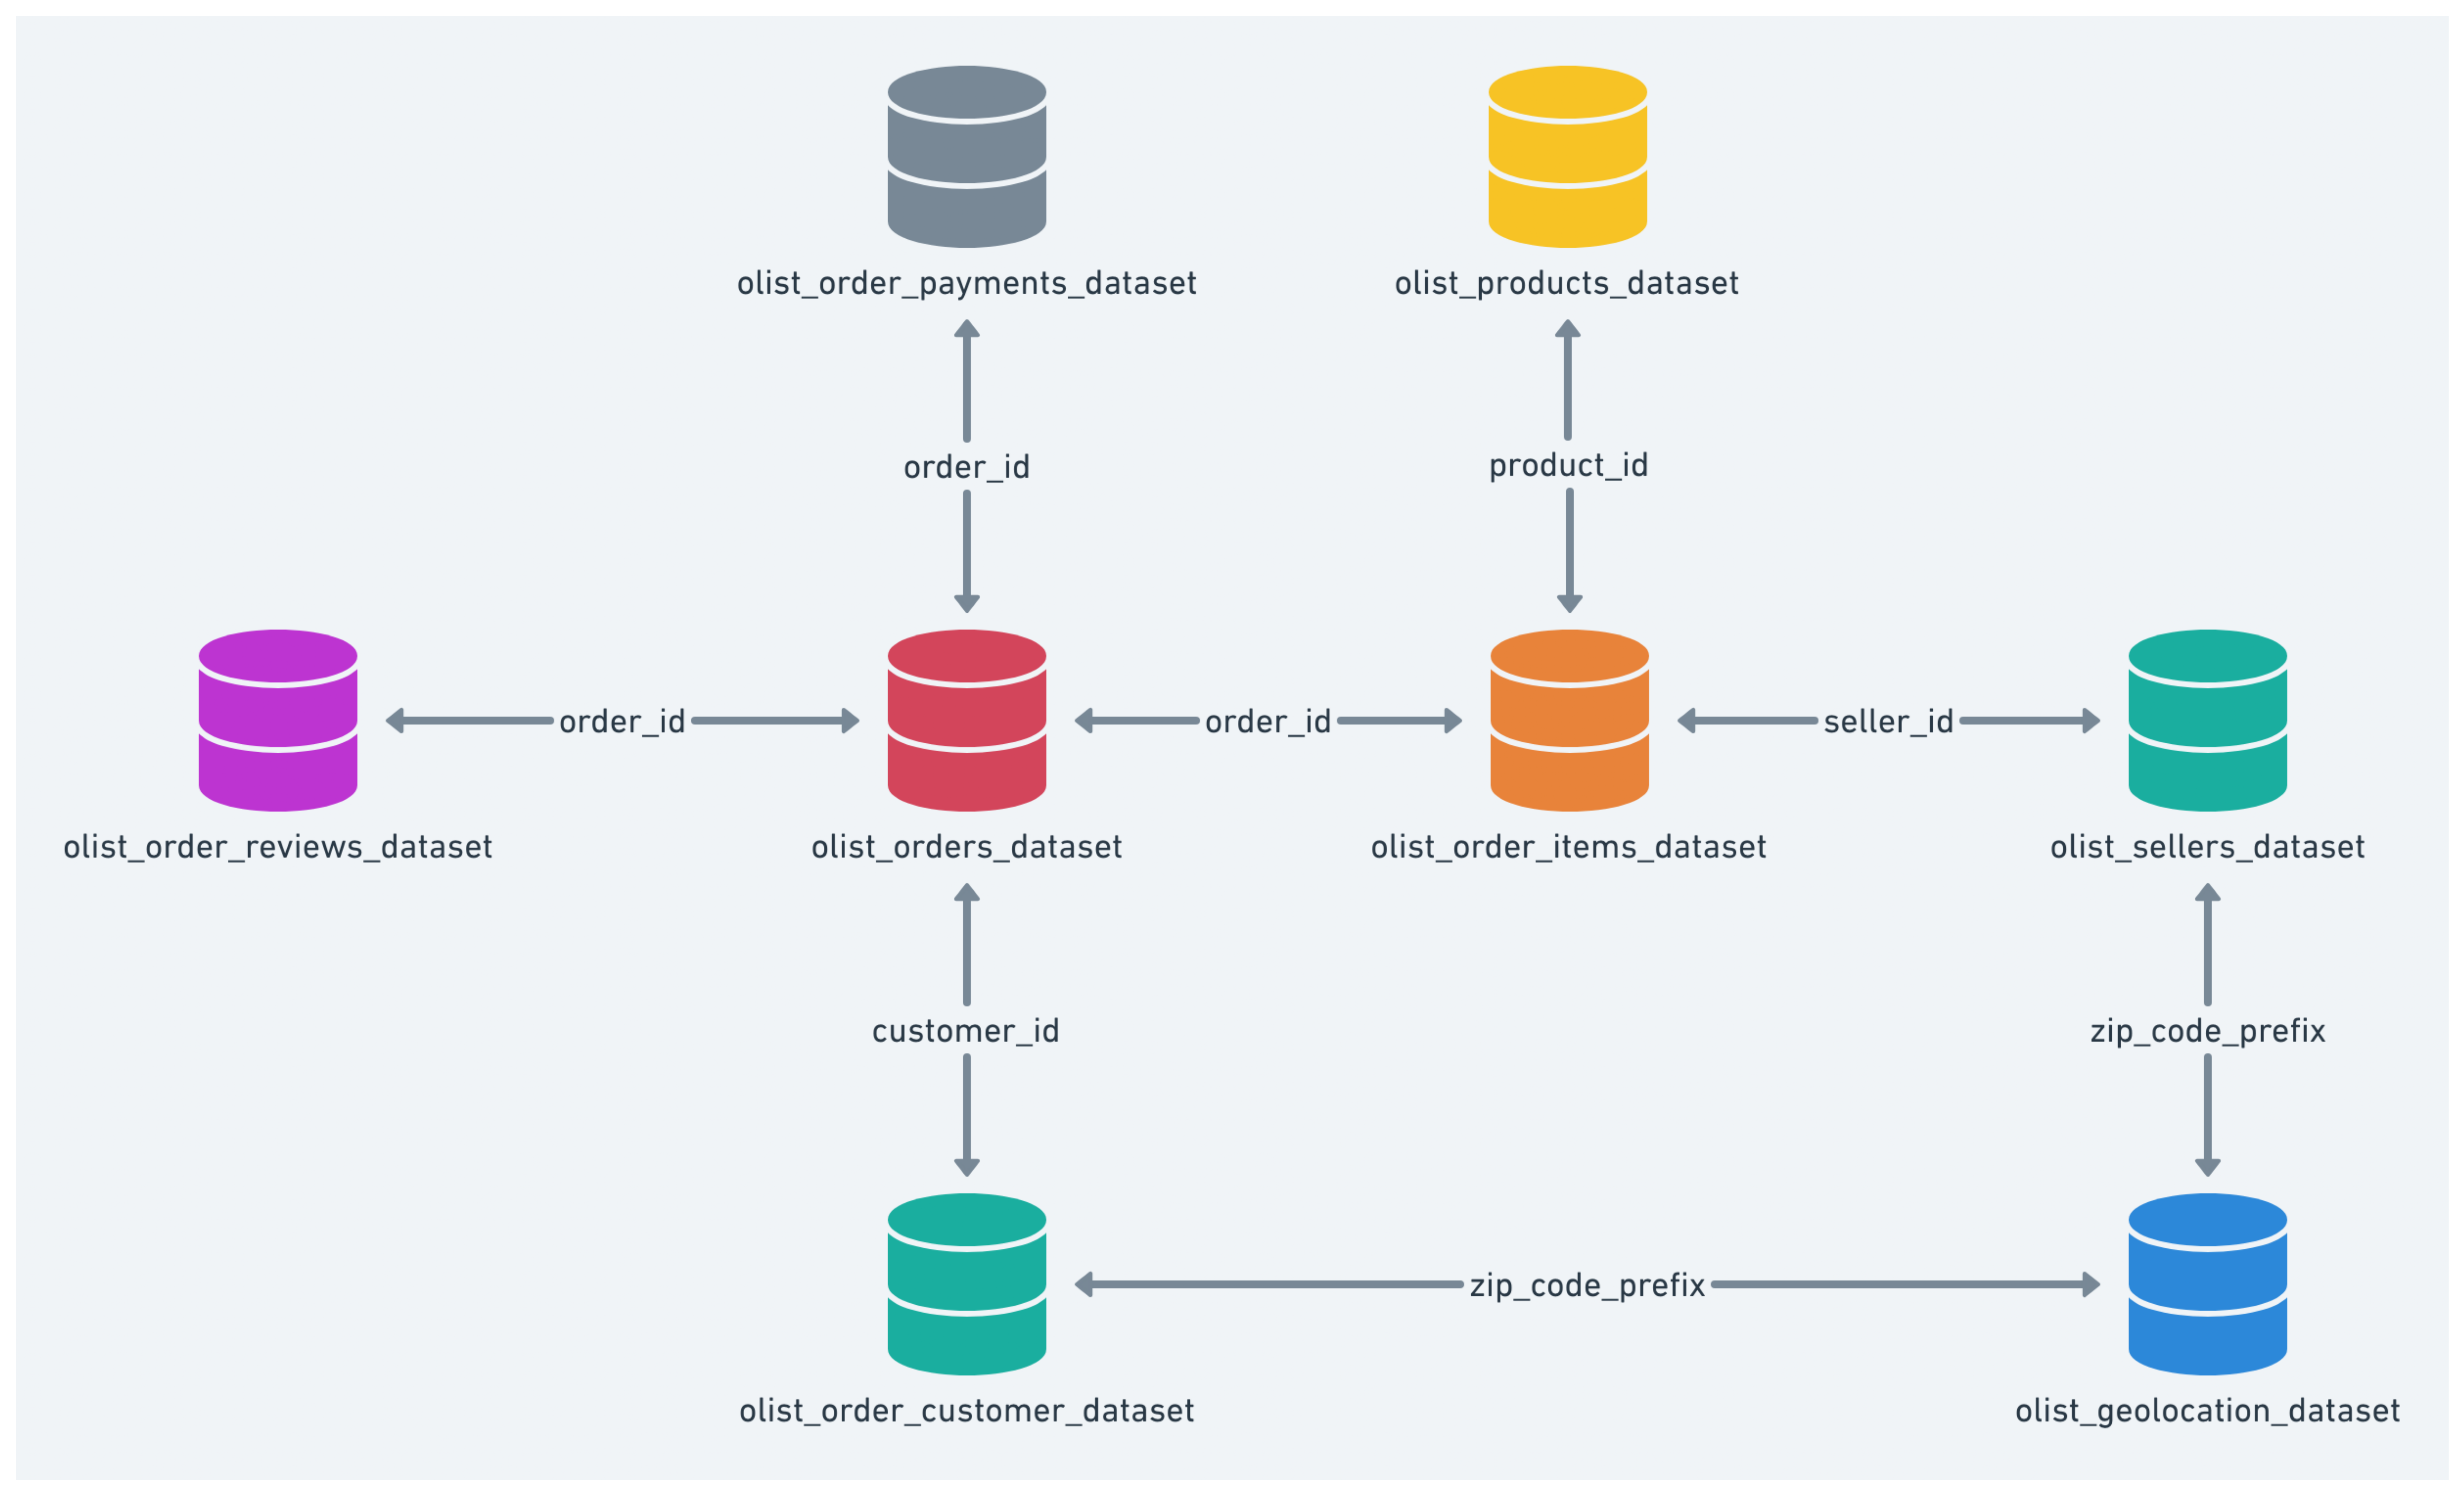

In [4]:
plt.figure(figsize=(20, 12), dpi = 300)
img = mpimg.imread('/Volumes/STORAGE/olist-freight-pricing-engine/img/other/sql_structure_olist.png')
plt.imshow(img)
plt.axis('off')
plt.show()

## 3. Data Loading and Merge

Granularity: **order_item**. Central table: `orders`.

Pre-merge treatments:
- `order_payments`: aggregated by `order_id` (sum of value, max installments, most frequent payment type)
- `order_reviews`: only the most recent review per order is kept
- `geolocation`: deduplicated by `zip_code_prefix` and joined twice (seller and customer)

In [5]:
# load all tables
legend_table   = pd.read_sql("SELECT * FROM product_category_name_translation", conn)
df_sellers     = pd.read_sql("SELECT * FROM sellers", conn)
df_customers   = pd.read_sql("SELECT * FROM customers", conn)
df_geolocation = pd.read_sql("SELECT * FROM geolocation", conn)
df_order_items = pd.read_sql("SELECT * FROM order_items", conn)
df_orders      = pd.read_sql("SELECT * FROM orders", conn)
df_products    = pd.read_sql("SELECT * FROM products", conn)
df_payments    = pd.read_sql("SELECT * FROM order_payments", conn)
df_reviews     = pd.read_sql("SELECT * FROM order_reviews", conn)

# geolocation: one record per zip code prefix (avoids row explosion on merge)
df_geo = df_geolocation.drop_duplicates(subset='geolocation_zip_code_prefix')

# payments: aggregate per order
df_payments_agg = (
    df_payments
    .groupby('order_id', as_index=False)
    .agg(
        payment_installments=('payment_installments', 'max'),
        payment_value=('payment_value', 'sum'),
        payment_type=('payment_type', lambda x: x.mode()[0])
    )
)

# reviews: keep most recent review per order
df_reviews_last = (
    df_reviews
    .sort_values('review_creation_date', ascending=False)
    .drop_duplicates(subset='order_id')
    [['order_id', 'review_score', 'review_creation_date']]
)

# main merge
df = (
    df_order_items
    .merge(df_orders,       on='order_id',   how='left')
    .merge(df_products,     on='product_id', how='left')
    .merge(legend_table,    on='product_category_name', how='left')
    .merge(df_sellers,      on='seller_id',  how='left')
    .merge(df_customers,    on='customer_id', how='left')
    .merge(df_payments_agg, on='order_id',   how='left')
    .merge(df_reviews_last, on='order_id',   how='left')
    .merge(
        df_geo.rename(columns={
            'geolocation_zip_code_prefix': 'seller_zip_code_prefix',
            'geolocation_lat': 'seller_lat',
            'geolocation_lng': 'seller_lng',
            'geolocation_city': 'seller_city_geo',
            'geolocation_state': 'seller_state_geo'
        }),
        on='seller_zip_code_prefix', how='left'
    )
    .merge(
        df_geo.rename(columns={
            'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
            'geolocation_lat': 'customer_lat',
            'geolocation_lng': 'customer_lng',
            'geolocation_city': 'customer_city_geo',
            'geolocation_state': 'customer_state_geo'
        }),
        on='customer_zip_code_prefix', how='left'
    )
)

print(f"Shape: {df.shape}")
df.head()

Shape: (112650, 43)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,review_score,review_creation_date,seller_lat,seller_lng,seller_city_geo,seller_state_geo,customer_lat,customer_lng,customer_city_geo,customer_state_geo
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,5.0,2017-09-21 00:00:00,-22.498183,-44.123614,volta redonda,RJ,-21.758076,-41.312633,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,4.0,2017-05-13 00:00:00,-23.566258,-46.518417,sao paulo,SP,-20.212393,-50.941471,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,5.0,2018-01-23 00:00:00,-22.264094,-46.158564,borda da mata,MG,-19.860439,-44.597972,pará de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,4.0,2018-08-15 00:00:00,-20.548228,-47.395897,franca,SP,-23.144923,-46.539830,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,5.0,2017-03-02 00:00:00,-22.931427,-53.133759,loanda,PR,-23.249008,-46.824961,varzea paulista,SP


# 4. Exploratory Data Analysis (EDA)

This section focuses on understanding the analytical base table, checking data quality, and creating BI-ready summaries. Plots generated in this notebook should be saved under `img/plots/`.

## 4.1 Dataset Overview

### 4.1.1 Shape and Memory Usage

In [6]:
print(f"Lines =  {df.shape[0]} \nColumns = {df.shape[1]}")


Lines =  112650 
Columns = 43


In [7]:
size_bytes = df.memory_usage(deep=True).sum()
print(f"Memory usage = {size_bytes / 1024 / 1024:.2f} MB")

Memory usage = 184.37 MB


### 4.1.2 Column Types and Completeness

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  object 
 1   order_item_id                  112650 non-null  int64  
 2   product_id                     112650 non-null  object 
 3   seller_id                      112650 non-null  object 
 4   shipping_limit_date            112650 non-null  object 
 5   price                          112650 non-null  float64
 6   freight_value                  112650 non-null  float64
 7   customer_id                    112650 non-null  object 
 8   order_status                   112650 non-null  object 
 9   order_purchase_timestamp       112650 non-null  object 
 10  order_approved_at              112635 non-null  object 
 11  order_delivered_carrier_date   111456 non-null  object 
 12  order_delivered_customer_date 

Based on `df.info()`, the dataset contains:

- 16 float columns
- 3 integer columns
- 24 object columns

### 4.1.3 First Rows

In [9]:
df.head(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,review_score,review_creation_date,seller_lat,seller_lng,seller_city_geo,seller_state_geo,customer_lat,customer_lng,customer_city_geo,customer_state_geo
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,5.0,2017-09-21 00:00:00,-22.498183,-44.123614,volta redonda,RJ,-21.758076,-41.312633,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,4.0,2017-05-13 00:00:00,-23.566258,-46.518417,sao paulo,SP,-20.212393,-50.941471,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,5.0,2018-01-23 00:00:00,-22.264094,-46.158564,borda da mata,MG,-19.860439,-44.597972,pará de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,4.0,2018-08-15 00:00:00,-20.548228,-47.395897,franca,SP,-23.144923,-46.539830,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,5.0,2017-03-02 00:00:00,-22.931427,-53.133759,loanda,PR,-23.249008,-46.824961,varzea paulista,SP


### 4.1.4 Order Date Coverage

Some date columns were loaded as `object`, so they should be converted to `datetime` before analyzing order periods, delivery times, or delays.

In [10]:
date_cols = [
      'shipping_limit_date',
      'order_purchase_timestamp',
      'order_approved_at',
      'order_delivered_carrier_date',
      'order_delivered_customer_date',
      'order_estimated_delivery_date',
      'review_creation_date'
  ]
for col in date_cols:
      df[col] = pd.to_datetime(df[col], errors='coerce')

In [11]:
dict_columns_dates = {}

for col in date_cols:
    dict_columns_dates[col] = {"Start": 0, "End": 0}
    # Grantidon que a coluna esta ordenada
    _line = df[col].sort_values().copy().reset_index(drop=True)
    dict_columns_dates[col] = {
          "Start": _line.iloc[0],
          "End": _line.iloc[-1]
      }

pd.DataFrame(dict_columns_dates)

,shipping_limit_date,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_creation_date
Start,2016-09-19 00:15:34,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04,2016-10-06
End,2020-04-09 22:35:08,2018-09-03 09:06:57,NaT,NaT,NaT,2018-10-25,NaT


**Observation:** The columns `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, and `review_creation_date` contain missing values.

These missing values may indicate that some order lifecycle events were not completed or were not recorded in the dataset. For example, an order may not have been approved, sent to the carrier, delivered to the customer, or reviewed.

They may also be related to data collection limitations. Before dropping or filling these values, the next step is to quantify missingness and compare it with `order_status`.

### 4.1.5 Dataset Volume

#### 4.1.5.1 Order Counts

In [12]:
order_number = len(df["order_id"])
order_number_uniques = len(df["order_id"].unique())

print(f"O df tem {order_number}  pedidos e {order_number_uniques} deidos unicos")

O df tem 112650  pedidos e 98666 deidos unicos


In [13]:
def formato_k(valor, pos):
    if valor >= 1000:
        return f'{valor/1000:g}k' # Divide por 1000 e adiciona 'k'
    return f'{valor:g}'

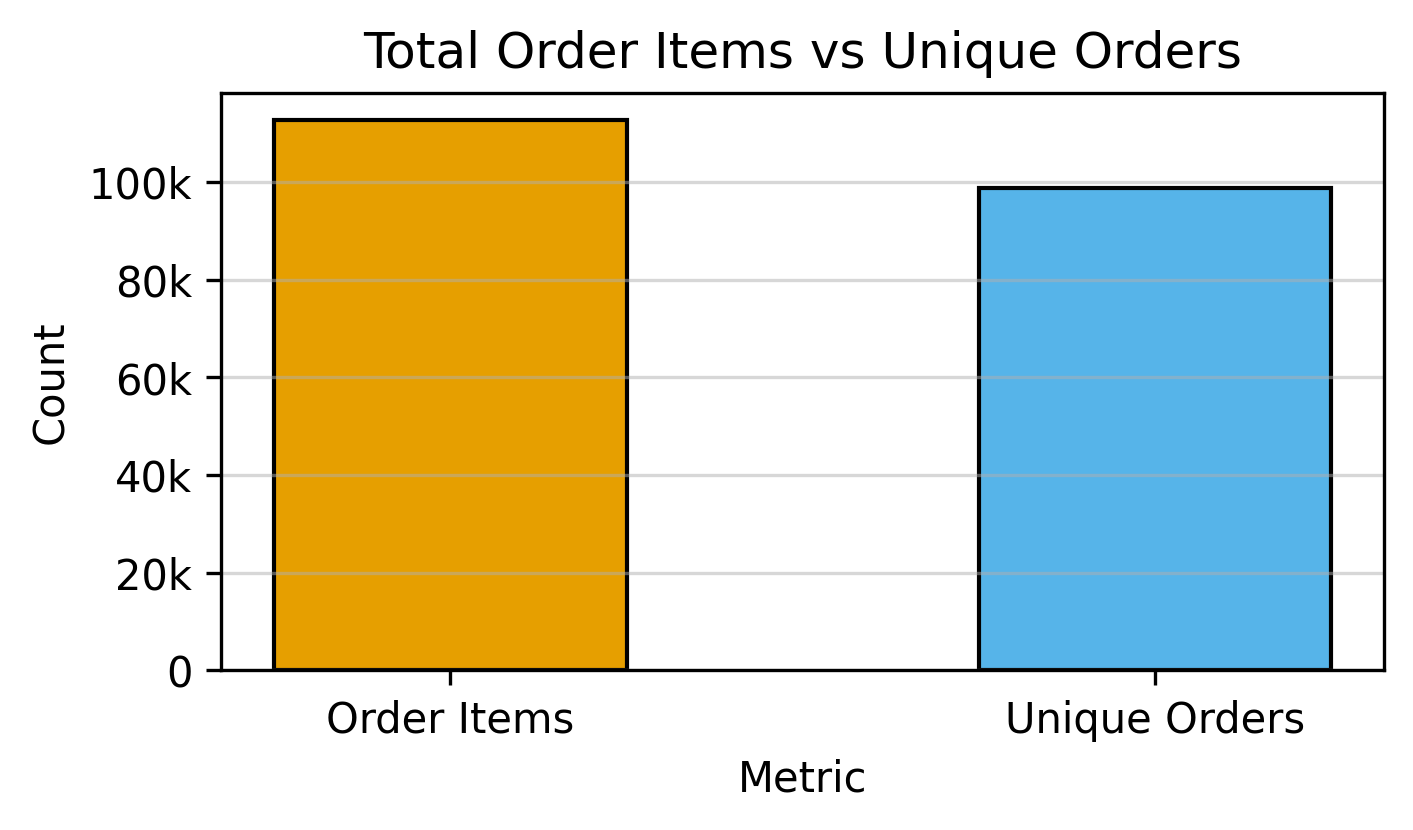

In [14]:
categories = ["Order Items", "Unique Orders"]
values = [order_number, order_number_uniques]
colors = ["#E69F00", "#56B4E9"]

fig, ax = plt.subplots(figsize=(5, 2.5), dpi=300)

ax.bar(categories, values, width=0.5, color=colors, edgecolor="black")

ax.yaxis.set_major_formatter(FuncFormatter(formato_k))

ax.set_title("Total Order Items vs Unique Orders")
ax.set_xlabel("Metric")
ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.5)

ax.set_xticks(categories)
ax.set_xticklabels(categories)

fig.savefig('/Volumes/STORAGE/olist-freight-pricing-engine/img/plots/order_items_vs_unique_orders.png', dpi=300, bbox_inches='tight')

plt.show()

#### 4.1.5.2 Unique Sellers, Customers, and Products

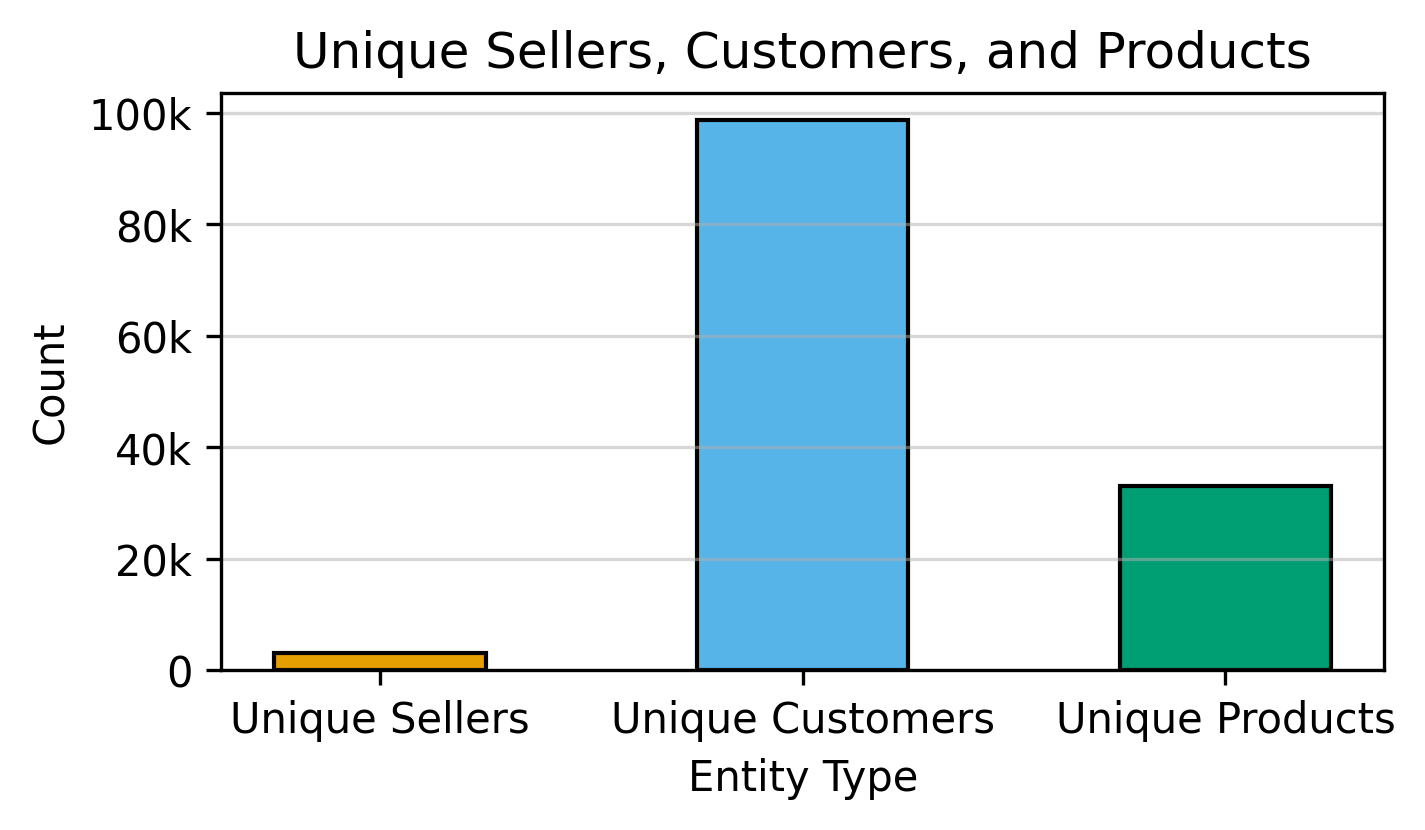

In [15]:
unique_sellers = df["seller_id"].nunique()
unique_customers = df["customer_id"].nunique()
unique_products = df["product_id"].nunique()

categories = ["Unique Sellers", "Unique Customers", "Unique Products"]
values = [unique_sellers, unique_customers, unique_products]
colors = ["#E69F00", "#56B4E9", "#009E73"]

fig, ax = plt.subplots(figsize=(5, 2.5), dpi=300)

ax.bar(categories, values, width=0.5, color=colors, edgecolor="black")

ax.yaxis.set_major_formatter(FuncFormatter(formato_k))

ax.set_title("Unique Sellers, Customers, and Products")
ax.set_xlabel("Entity Type")
ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.5)

ax.set_xticks(categories)
ax.set_xticklabels(categories)

fig.savefig('/Volumes/STORAGE/olist-freight-pricing-engine/img/plots/unique_sellers_customers_products.png', dpi=300, bbox_inches='tight')

plt.show()